# 분류

## <span style="background-color:#fae0f0; color:#c0156d; padding:4px; border-radius:5px;"> 1. 분류의 이해 </span>

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 1.1 회귀 v.s. 분류 </span>
#### 1. **회귀** (Regression)
- 대푯값으로 연속적인 숫자값을 예측하는 지도학습의 방법
- 즉, 주어진 데이터(X, 독립변수)를 기반으로 정답(Y, 종속변수)을 잘 맞추는 함수
- <span style="color:blue"> **연속형 변수 예측**</span>에 활용!

#### 2. <span style="background-color:yellow">**분류**</span> (Classification)
- 입력된 데이터를 주어진 항목들로 나누는 지도학습의 방법
- 즉, 기존 데이터가 어떤 레이블에 속하는지 패턴을 알고리즘으로 인지한 후, 새롭게 관측된 데이터에 대한 **레이블을 판별**하는 것
- <span style="color:blue"> **범주형 변수 예측**</span>에 활용!<br><br>
- <span style="background-color:yellow">**활용되는 머신러닝 알고리즘**</span>
  - **로지스틱 회귀**(Logistic Regression) : 선형 관계성 기반 분류
  - **결정 트리**(Decision Tree) : 데이터 균일도에 따른 규칙 기반 분류
  - **서포트 벡터 머신**(SVM) : 개별 클래스 간 최대 마진을 효과적으로 찾아 분류
  - **최소 근접**(Nearest Neighbor) : 근접 거리 기준 분류

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 1.2 이진 분류 v.s. 다중 분류 </span>

#### 1. **이진 분류**
- 예측하려는 변수가 가질 수 있는 값이 **True or False**

#### 2. **다중 변수**
- 예측하려는 변수가 가질 수 있는 값이 **3개 이상**

## <span style="background-color:#fae0f0; color:#c0156d; padding:4px; border-radius:5px;"> 2. 분류 모델 </span>

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 2.1 로지스틱 회귀 </span>

1. **개념** : **이진 분류 문제**를 푸는 대표적 알고리즘
   1. 독립 변수의 선형 조합(선형회귀)에 로지스틱 함수를 적용해, **출력값을 0-1사이로 변환**해주는 것!
2. **목표** : 샘플이 특정 **클래스에 속할 확률**을 추정해 **기준치에 따라 분류**
3. **예** : 이메일이 스팸인지 아닌지, 특정 질병을 갖고 있는지 아닌지
4. **필요성**
   1. 문제 : 분류 사례에 일반 선형 회귀를 적용하면 예측력이 떨어짐<br><br>
   2. 해결 방법 : 출력이 **0-1** 사이이며, **S자** 형태의 함수가 필요 => <span style="background-color:yellow">**시그모이드 함수**(Sigmoid function)</span>
      1. 입력값이 커지면 1에 수렴, 작아지면 0에 수렴
      2. 입력값($x$)이 $(-\infin, \infin)$일 때, 출력값($y$)은 0~1의 값을 가짐
      3. 즉, 출력값이 특정값이 이상이면 1(True), 특정값 이하면 0(False)로 정해, 이진 문제 풀이에 사용

5. **코드 예시**
    ```python
    import numpy as np
    import matplotlib.pyplot as plt

    def sigmoid(x):
        return 1/(1+np.exp(-x)) # 시그모이드 함수 식

    x = np.arange(-5.0, 5.0, 0.1)
    y = sigmoid(x)

    plt.plot(x, y, 'g')
    plt.plot([0,0],[1.0,0.0], ':') # 가운데 점선 추가
    plt.title('Sigmoid Function')
    plt.show()
    ```
6. **활용법**
   1. **수식**
      1. $H(x)=\frac{1}{1+e^{-(wx+b)}}=sigmoid(wx+b)=\sigma(wx+b)$<br>

   2. **학습 단계** : 직선($wx+b$)찾기
      1. 상황: 우리에게는 이미 독립변수($x$)와 결과($y=0$ 또는 $1$)가 있는 데이터가 있음.
      2. 과정
         1. 데이터로부터 각 $x$에 대응하는 **확률**($p$)의 경향성 파악
         2. 이 확률($p$)을 **로지트 함수**에 통과시켜서 **실수**($z$)로 변환
            - logit = Odd(승산)의 로그값
            - Odd = $\frac{p}{1-p}$
            - 로지트 함수 : 시그모이드 함수의 역함수
         3. 이 실수값들을 가장 잘 설명하는 최적의 **기울기**($w$)와 **절편**($b$)을 찾아내어 **직선 방정식**($z = wx+b$)을 완성함. 
      3. 결과: 이제 우리는 $x$만 넣으면 $z$가 나오는 직선 $wx+b$을 가지게 됨.<br>

   3. **예측 단계** : 확률($p$) 뽑기
      1. 상황: 결과($y$, 0-1사이의 값, ~의 여부)를 모르는 새로운 데이터 $x$가 들어옴
      2. 과정
         1. 학습 단계에서 완성한 직선 방정식($wx+b$)에 새로운 $x$를 대입하여 $z$값을 구함
         2. 이 $z$값은 무한대의 실수이므로, 다시 0~1 사이의 확률로 바꾸기 위해 **시그모이드 함수**에 집어넣기
         3. 시그모이드가 뱉어낸 **최종 확률**($p$)을 보고 이진 문제 풀이에 활용
<br><br>
7. **가중치 변화에 따른 그래프 변화**
   1. $w$ : **그래프의 기울기 변화**    
      - $w=0.5$,  $w=1.0$,  $w=2.0$
      - 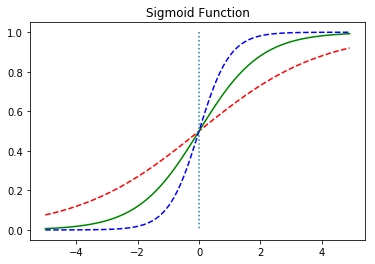
        ```python
        # ...생략
        y1 = sigmoid(0.5*x)
        y2 = sigmoid(x)
        y3 = sigmoid(2*x)
        # 생략...
        ```
   2. $b$ : **그래프의 위치 변화**
      - $b=0.5$,  $b=1.0$,  $b=1.5$
      - 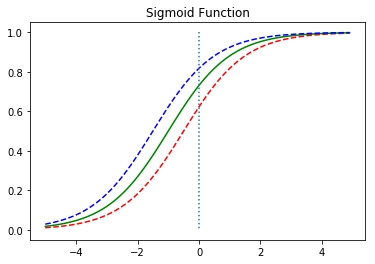
        ```python
        # ...생략
        y1 = sigmoid(x+0.5)
        y2 = sigmoid(x+1)
        y3 = sigmoid(x+1.5)
        # 생략...
        ```

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 2.2 의사결정나무 </span>

1. **개념** : 조건에 따라 데이터를 분류해, 최종적으로 **데이터가 순수한 label의 집합으로 구성될 때까지 분류를 반복**하는 방법
   1. 독립 변수의 선형 조합(선형회귀)에 로지스틱 함수를 적용해, **출력값을 0-1사이로 변환**해주는 것!

2. **구성 요소**
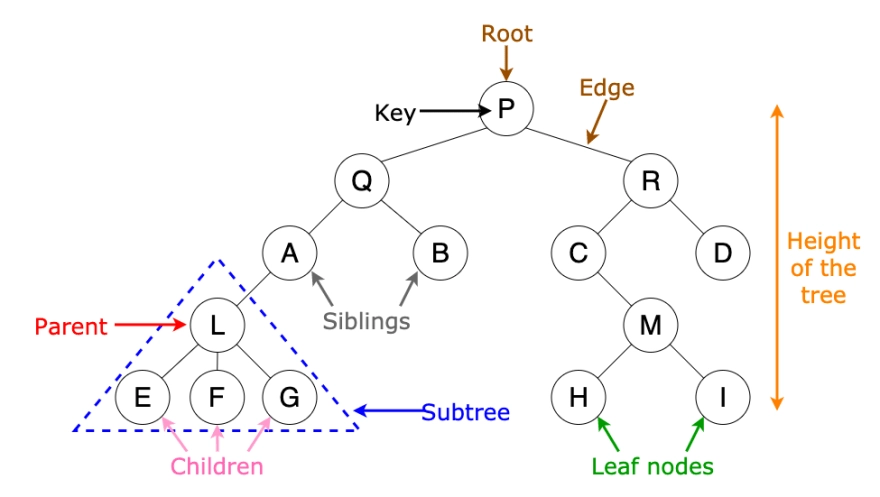
    - **Root Node** : 가장 상위의 노드
    - **Parent Node** : 상대적으로 상위에 있는 노드
    - **Child Node** : 하나의 노드로부터 분리된 2개 이상의 노드들
    - **Binary Node** : Tree 중, Children이 최대 2개뿐인 Tree
    - **Leaf Nodes** : Child node가 없는 노드 (모델에서 label에 해당)
    - **Edge** : Parent Node - Child Node 간 연결선
    - **Height** : 특정 노드에서, 가장 먼 Leaf node까지의 경로에 있는 edge 개수
    - **Depth** : Root Node에서 특정 노트에 도달하기 위한 Edge 개수

#### <span style="background-color:yellow; color:black; padding:4px; border-radius:5px;"> 2.2.1. **CART** </span> : 이진분할(Classification And Regression Tree) 알고리즘
> CART : 데이터셋을 **임계점을 기준으로 두 child로 나누는 알고리즘**으로, 가장 널리 사용되는 의사결정나무 알고리즘
<br>

- **임계값 나누는 기준** : 불순도(지니계수)가 낮아지는 방향
- **불순도** : 데이터 집합에서, 서로 다른 범주(Class)가 섞여있는 정도
- <span style="background-color:yellow">**지니계수**</span> : 불순도를 나타내는 지표 -> 통계적 분산정도를 정량화해 표현한 값 (0~1)
  - 지니계수를 통해, <span style="color:blue"> 서로 다른 클래스가 얼마나 섞여있는지</span> 알 수 있음
    - 수식 ( ${P_i}$ = class $i$의 비율 )
      - $Gini=1-\sum_{i=1}^n{P_i}^2$

1. **CART 알고리즘의 단계**
    1. 임계값 설정
    2. 불순도 감지 알고리즘

2. **한계** : 당장의 지니계수를 낮추는 판단만해, 가장 효율적인 대안 제시 X

3. **실제 학습시 고려가 필요한 것들**
   1. **Hyperparameter** 설정<br><br>
       | `min_samples_split` | 노드가 분할되려면 가져야 하는 최소 샘플(데이터) 수 |
       | --- | --- |
       | `min_samples_leaf` | 리프 노드가 갖는 최소 샘플 수 |
       | `min_weight_fraction_leaf` | `min_samples_leaf`와 같지만 가중치가 부여된 전체 샘플 수에서의 비율 |
       | `max_leaf_nodes` | 리프 노드의 최대 개수 |
       | `max_features` | 각 노드에서 분할에 사용할 feature의 최대 수 |
    
    <br>

   2. **시각화**
      1. 시각화를 통해 분류가 잘 이뤄졌는지 확인 가능
         1. 예 : `min_samples_leaf` 를 통해 최소 샘플 수를 제어하여 **과적합 방지**
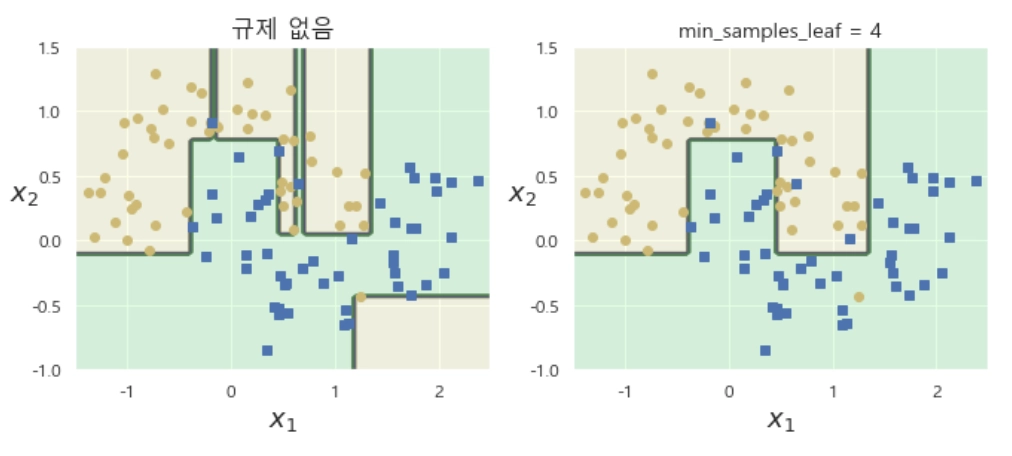

   3. **Prunning**(가지치기)
      1. **개념** : 불필요한 노드 지우기
      2. **필요성** : 노드가 너무 많아지면, 과적합의 확률이 높아짐 => Prunning을 통해 일반화 성능을 높일 수 있음
      3. **효과** : 깊이가 줄고 결과의 개수가 줄어듦


### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 2.3 SVM (Support Vector Machine) </span>
1. **개념** : 클래스를 분류할 수 있는 다양한 경계선 중 **최적의 라인**을 찾아내는 알고리즘<br><br>
   1. <span style="color:blue"> 즉, 데이터를 분리하는 **초평면**(Hyperplane)중에서 <br>**데이터들과 가장 거리가 먼 초평면을 선택해 분리**하는 지도 학습 기반의 이진 선형 분류 모델</span>
<br><br>
   2. **활용처** : 명확하게 분류되는 데이터 집단 / 고차원 공간(다수의 Feature)
      1. => 패턴 인식, 이미지 분석, 바이오인포매틱스 등 다양한 머신러닝 응용 분야에서 활용
<br><br>
   3. **구성**
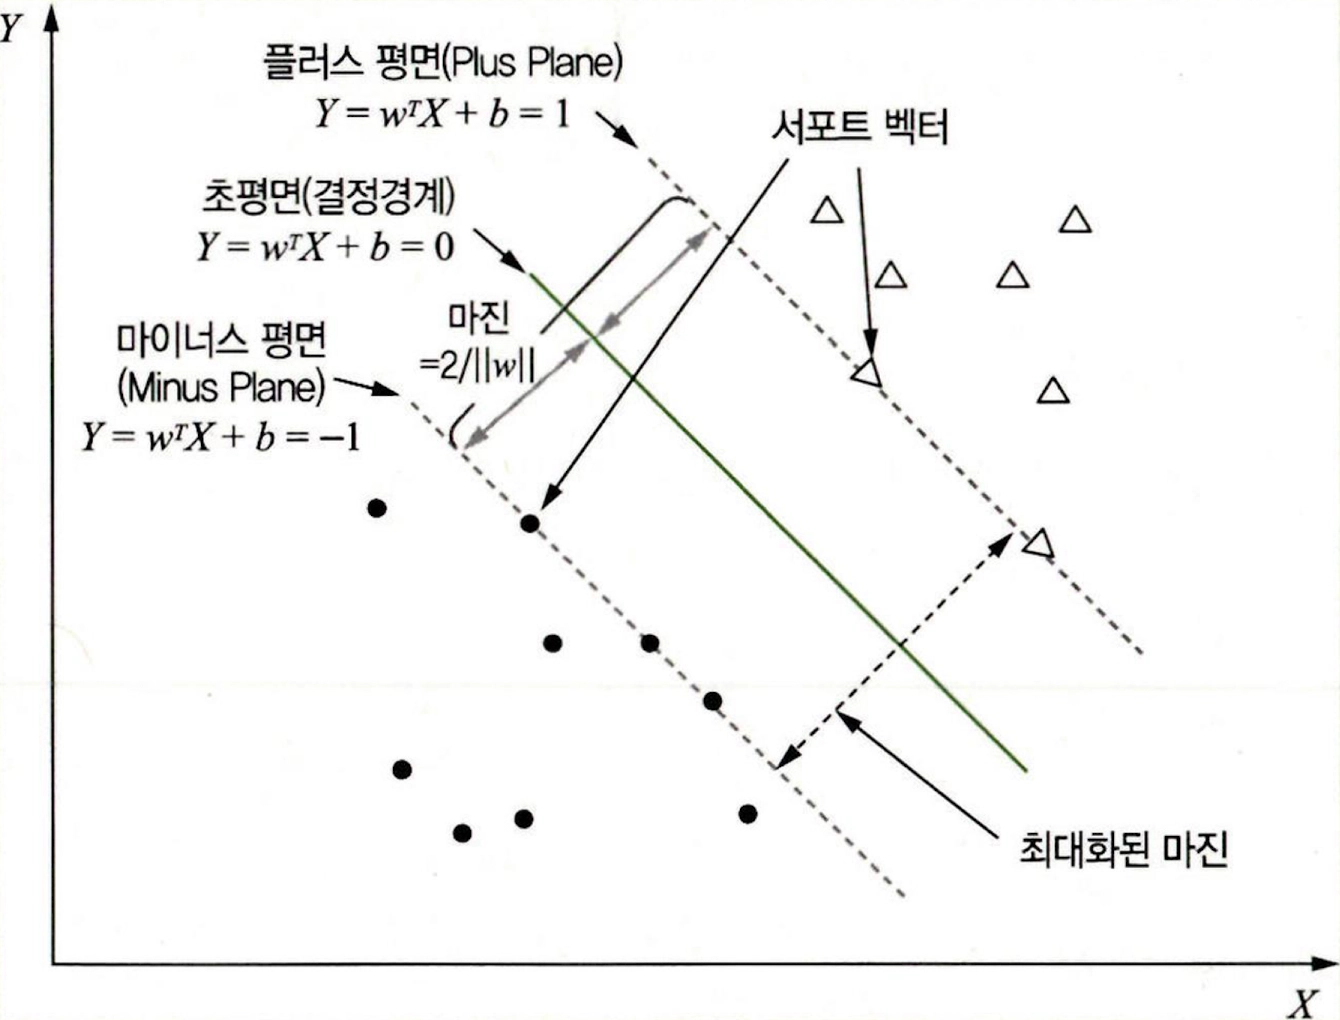
      1. **Suport Vector** : 데이터 중 결정 경계와 가장 가까이에 있는 데이터들의 집합
      2. **Desicion Boundary** : 데이터 분류의 기준이 되는 경계
      3. **Margin** : 결정 경계 ~ 서포트 벡터의 거리 (여유 공간)
      4. **Hyperplane** (초평면) : $n$차원 공간의 $n-1$차원 평면
      5. **Slack Variables** (슬랙 변수/여유 변수) : 완벽한 분리가 불가능할 때 분류를 위해 허용된 오차에 대한 변수
<br><br>
   1. **최적의 선(결정 경계) 찾기**
      - <span style="color:blue"> 결정 경계는 데이터로부터 가장 멀리 떨어져 있는 것이 좋음</span>
      - 따라서, **SVM은 Margin이 가장 큰 경우**를 선택!
<br><br>
   1. **장단점**<br><br>
      <span style="color:green"> 1. **장점** </span>
         1. 데이터가 적을 때 효과적 : 서포트 벡터만으로 결정 경계를 만들 수 있으므로
         2. 연산량 최소화 : 새로운 데이터 입력 시, 전체 데이터와의 거리 계산 필요없이 서포트 벡터와의 겨리만 계산하면 되므로
         3. 뛰어난 정확성, 비선형 모델 분류 가능
         4. 상대적으로 과대 적합의 가능성이 낮음, 노이즈의 영향이 적음

      <span style="color:red"> 2. **단점** </span>
         1. 데이터 전처리 과정이 중요
         2. 데이터가 많아질 수록 최적화를 위한 평가 과정이 많아져서 속도가 느림

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 2.4 KNN (K-Nearest Neighbor)</span>

1. **개념** : "*비슷한 특성을 가진 데이터들은 서로 가까이 있는다*"는 특성을 활용한 분류 알고리즘
   1. <span style="color:blue"> 즉, 데이터로부터 **거리가 가까운 k개의 다른 데이터 레이블을 참조**해 분류</span>
<br><br>
2. <span style="background-color:yellow">**KNN 알고리즘 계산 순서**</span><br><br>
   1. **데이터 준비**
      1. **미리 학습하는 과정 X**  -> 즉 별도의 모델이 없음
      2. 데이터를 준비, 각 데이터는 특정 벡터와 레이블로 구성
   2. **K값 설정**
      1. K : 가장 가까운 이웃의 개수, 보통 홀수로 설정 (동점 발생 방지를 위해 짝수는 지양)
      2. 최적의 K 선택하기
         1. 보통 학습용 데이터 개수의 제곱근으로 설정
         2. 너무 크면 근접성이 떨어져 과소적합이, 너무 작으면 이상값과 이웃이 될 가능성...ㅜㅜ
         3. Class가 3개 이상인 경우, 클래스, 데이터의 세부 값 등을 종합적으로 고려해야함
   3. **거리 계산**
      1. 새로운 데이터가 입력되면, 이 값 - 기존 모든 데이터 간 거리를 계산
         1. 유클리드 거리, 맨해튼 거리 등을 사용
   4. **가장 가까운 K개의 이웃 선택**
      1. 가장 작은 거리 값을 가진 K개의 데이터를 선택 = 가장 가까운 이웃
   5. **분류하기**
      1. K개의 이웃 중 가장 많이 등장하는 클래스
      2. K=홀수임에도 동점이 나올 경우, 무작위로 선택하고나, 더 가까운 이웃에 해당하는 클래스로 분류
<br><br>
3. **장단점**<br><br>
   <span style="color:green">1. **장점** </span>
      1. 범주를 나눈 기준을 몰라도 데이터를 분류할 수 있음
      2. 입력데이터만 있으면 바로 예측값을 구할 수 있음 (별도의 학습과정 X)
      3. 쉬운 이해, 간단한 구현
      4. 용이한 추가 데이터 처리
      5. 원본 데이터 그대로 저장 (훈련 데이터 요약, 일반화된 모델 X)

   <span style="color:red"> 2. **단점** </span>
      1. 테스트 데이터 개수에 따라 시간이 오래걸릴 수 있음
      2. 분류 시 전체 데이터를 계산에 활용하기 때문에, 학습 데이터 양에 따라 시간이 오래걸릴 수 있음
      3. K값 결정이 어려움
      4. 수치형 데이터가 아닐 경우, 유사도 정의가 어려움
      5. 분류 성능이 이상치에 영향을 크게 받음

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 2.5 앙상블 (Ensemble)</span>

1. **개념** : **여러 개의 개별 분류 모델들을 결합**해, 하나의 분류 모델보다 더 좋은 성능을 내는 머신러닝 기법
   1. 즉, 여러 `Weak Classifier`를 병렬/직렬로 결합 -> `Strong Classifier`로 만드는 것
   2. 여러 개의 모델을 학습 시킴 -> **모델들의 예측 결과를 종합해 최종 예측**

2. **종류**
   - **보팅** : 다른 알고리즘의 모델을 병렬로 사용
   - **배깅** : 동일 알고리즘의 모델을 병렬로 사용
   - **부스팅** : 동일 알고리즘의 모델을 직렬(=순차적)로 사용

## <span style="background-color:#fae0f0; color:#c0156d; padding:4px; border-radius:5px;"> 3. 분류 평가 지표 </span>

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 3.1 혼동 행렬 </span>

1. **혼동 행렬의 개념**
     - 분류 모델의 예측 결과를 <span style="color:green">**정확한 예측**</span>과 <span style="color:red">**잘못된 예측**</span>으로 구분해 나타낸 표 (행렬)
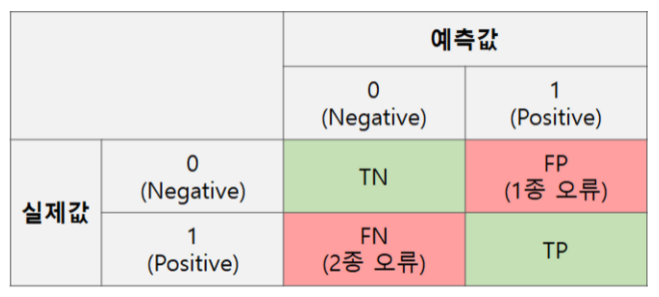
     - 경우의 수 : 예측성공여부(T/F) + 예측값(P/N)
       - **TP**: 모델이 참(P)이라고 예측해서 정답을 맞춤(T)
       - **FP**: 모델이 참(P)이라고 예측해서 정답을 맞추지 못함(F)
       - **FN**: 모델이 거짓(N)이라고 예측해서 정답을 맞추지 못함(F)
       - **TN**: 모델이 거짓(N)이라고 예측해서 정답을 맞춤(T)
<br><br>
1. **혼동 행렬 활용 분류 모델 평가 지표**
<br><br>
   1. <span style="background-color:yellow"> **정확도(Accuracy)**</span> : 모델이 입력 데이터를 얼마나 정확하게 예측하는가 (전체 중 참의 비율, 0-1)
      1. 정답 레이블의 비율이 불균형시, 정확도 신뢰 X 

   2. <span style="background-color:yellow">**정밀도(Precision)**</span> : 참이라고 예측한 경우, 실제 참의 비율 (0-1)
      1. 수식 : $\frac{TP}{TP + FP}$
      2. 높을 수록, 거짓을 참으로 예측한 정도가 낮음

   3. <span style="background-color:yellow">**재현도(Recall)**</span> : 실제로 참인 경우, 참으로 예측하는 비율 (0-1)
      1. 수식 : $\frac{TP}{TP + FN}$
      2. 높을 수록, 참을 거짓으로 판단한 정도가 낮음

   4. 정확도 - 재현도는 상충 (Trade-off)
<br><br>
1. **정밀도, 재현도 예시**
<br><br>
   1. `Recall`이 중요한 경우
      1. 상황 : 암환자 판단 :FN(*암환자가 아니라 했는데 실제로 암환자인 경우*)를 줄여야 함
      2. 조치 : 임계치(Threshold) 낮추기
         1. 참으로 예측하는 경우(TP, FP)를 늘림으로써, FN을 낮춤. -> 차라리 FP를 늘리는게 나은 경우

   2. `Precision`이 중요한 경우
      1. 상황 : 스팸 여부 판단 : FP(*스팸이 아니었는데, 스팸이라고 한 경우*)를 줄여야 함
      2. 조치 : Threshold 높이기
         1. 거짓으로 예측하는 경우(TN, FN)을 늘림으로써, FP를 낮춤 -> 차라리 FN를 늘리는게 나은 경우

   3. **정리**
      1. <span style="color:blue"> Threshold 조정을 통해 정밀도, 재현도를 조정할 수 있음</span>
         1. `Threshold` down -> `Positive` down -> `Precision` down
         2. `Threshold` up -> `Positive` up -> `Recall` down

   4. **정밀도&재현도 그래프**를 통해 `Threshold` 결정 --> 예측 오류 최소화
      1. 모델의 성능을 시각적으로 파악 가능
      2. 두 선이 만나는 지점을 `Threshold`으로 정하기
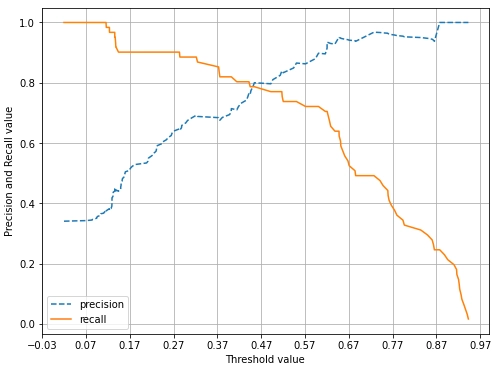

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 3.2 F1-Score </span>
1. <span style="background-color:yellow">**개념** : 정밀도(Precision) - 재현도(Recall)의 조화 평균</span>
   1. 조화평균 : 주어진 값들의 역수를 산술 평균한 후, 다시 역수를 취한 값
   2. **Precision-Recall의 균형**을 효과적으로 평가하기 위해 사용

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 3.3 ROC / AUC Curve </span>
1. <span style="background-color:yellow">**ROC Curve**</span>
    - **개념** : 얼마나 분류가 잘 됐는지 보여주는 그래프, x축 : FPR, y축 : TPR
      - **TPR** : 참인 것들 중 참이라고 예측한 비율 (=Recall, $\frac{TP}{TP + FN}$)
      - **FPR** : 거짓인 것들 중 참이라고 잘 못 예측한 비율 ($\frac{FP}{TN + FP}$)
    - 완벽한 분류기는 나올 수 없으나, 현실적 한계를 고려해, 적절히 타협한 최선의 ROC Curve를 도출하는 것이 중요
      - 좌상단으로 붙어있는 ROC Curve일수록 더 좋은 이진 분류기
![ROC Curve.webp](<attachment:ROC Curve.webp>)

2. <span style="background-color:yellow">**AUC Curve**</span>
    - **개념** : ROC와 x축 사이의 면적 (=적분값)
      - $0.5 \le AUC \le 1$
      - <span style="color:blue"> 1에 가까울 수록 좋은 분류 성능!</span>

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 3.4 다중 분류 평가 지표 </span>
> 위 혼동행렬, F1-Score, ROC/AUC Curve는 모두 이진 분류 평가 지표임.<br>
> 다중 분류 평가를 위해선, 이진 분류 평가 지표를 사용해 **클래스 별로 점수를 구한 뒤 적절히 평균**을 내야함
<br>

1. **Macro Average** : 클래스 별로 구한 평가 지표의 평균
   1. 모든 클래스가 유사한 중요도를 갖는 경우
2. **Weighted Average** : 클래스 별로 구한 평가 지표의 가중 평균
   1. 빈도가 높은 클래스에 더 큰 가중치 부여
3. **Micro Average** : 모든 클래스의 예측 결과를 더해 전체적인 성능을 평가하는 지표
   1. 클래스에 상관없이 전체적인 성능을 평가할 때
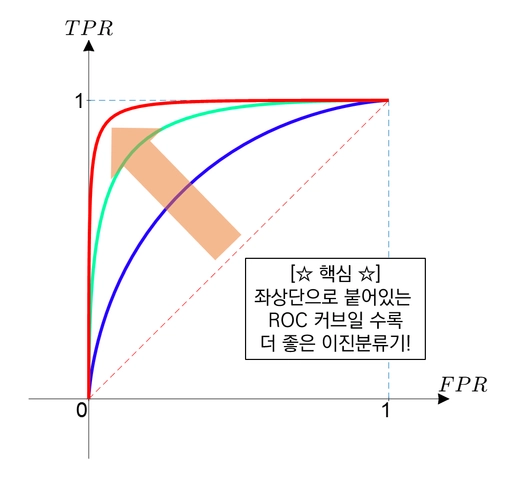

## <span style="background-color:#fae0f0; color:#c0156d; padding:4px; border-radius:5px;"> 4. 하이퍼파라미터 </span>

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 4.1 하이퍼파라미터 최적화 </span>
1. **하이퍼파라미터** : <span style="color:green"> 모델 학습 시작 전, 사용자가 직접 설정하는 변수</span> -> 학습 과정에 반영됨
    - ex. decision tree의 `max_depth`, random forest의 `n_estimators`

1. **하이퍼파라미터 최적화** : Tuning을 거쳐 적절한 하이퍼파라미터를 찾아 모델 성능을 향상 시키는 것
    - 최적화 과정
      - Hyperparameter 탐색 범위 설정 (최적 값을 찾고 싶은 하이퍼파라미터의 범위를 설정)
      - 평가 지표 계산 함수 (=성능 평가 함수) 정의
      - 1단계에서 샘플링한 Hyperparameter 값을 사용해 검증 데이터로 정확도 평가
      - 위 단계를 특정 횟수 반복해, 정확도 결과를 보고 하이퍼파라미터의 범위를 좁힘

### <span style="background-color:#e6fae0; color:#42c015; padding:4px; border-radius:5px;"> 4.2 하이퍼파라미터 최적화 방법 </span>
> 성능 평가 시, 검증 데이터(validation data) 활용<br>
> 하이퍼파라미터 최적화를 자동화하는 `Optuna` 라이브러리 활용 가능 (교차 검증 기반으로 모델의 일반화 성능 평가)

1. <span style="background-color:yellow">**Grid Search**</span>
   1. **개념** : 정해진 범위에서 Hyperparameter를 **모두** 순회해, 가장 좋은 성능을 내는 값을 찾는 기법
   2. **장점** : 범위가 넓고, step이 작을 수록 꼼꼼하게 전 범위를 탐색해, 최적의 해를 정확히 찾을 수 있음
   3. **단점** : 시간이 오래 걸림
   4. **적용** : 넓은 범위, 큰 step을 활용해 범위를 좁힘
   5. **코드** : `GridSearchCV` (scikit-learn)

2. <span style="background-color:yellow">**Random Search**</span>
   1. **개념** : 정해진 범위에서 Hyperparameter를 **무작위로** 순회해, 가장 좋은 성능을 내는 값을 찾는 기법
   2. **장점** : Grid Search보다 속도가 빠름
   3. **단점** : 무작위라 정확도가 떨어짐 -> 적은 사용 빈도
   4. **코드** : `RandomSearchCV` (scikit-learn)

3. <span style="background-color:yellow">**Bayesian Optimization**</span>
   1. **개념** : 사전 정보를 바탕으로, 최적 Hyperparameter값을 확률적으로 추정해 탐색하는 기법
   2. **특징** : 가우시간 프로세트 기반의 모델(대리모델, Surrogate Model), 여러 개의 Hyperparameter에 대해 **Aquisition Function**(획득 함수)을 적용했을 때, **가장 큰 값**이 나올 확률이 높은 지점을 찾아냄
      1. 위 두 방법보다 상대적으로 효율적!
   3. **방법**
      1. 초기 값 몇 개를 무작위로 실험
      2. 실험 결과를 바탕으로, 어떤 파라미터의 조합이 좋을지를 확률 모델로 예측 (Surrogate Model)
      3. Aquisition Function을 사용해 다음 실험 조합(탐색 지점)을 선택
      4. 결과 반영, 다시 반복
   4. **코드** : `bayes_opt`